# 04. 월별 거래량 시계열 예측 — SARIMA vs Prophet vs LightGBM

이 노트북은 `data/raw_api_collected_all.csv`(국토교통부 아파트 매매 실거래가 수집 결과)를
**전국 월별 거래건수 시계열**로 집계한 뒤, 3가지 시계열 예측 모델을 비교합니다.

- **SARIMA(statsmodels)**: 전통적인 통계 기반 시계열 모델
- **Prophet(Meta)**: 추세·계절성·휴일 효과를 분해해서 예측하는 모델
- **LightGBM**: lag 피처(지난 N개월 거래건수)를 입력으로 쓰는 회귀 기반 ML 모델

세 모델의 예측 정확도를 **MAPE(Mean Absolute Percentage Error)**로 비교해 가장 적합한 모델을 선택합니다.

> ⚠️ **데이터 기간에 대한 솔직한 한계**
> 현재 수집된 데이터는 **11개월(2025-07~2026-05)** 뿐입니다. 계절성(연간 주기)을 제대로 학습하려면
> 보통 24개월 이상이 필요하므로, 이 노트북의 계절성 추정은 제한적입니다. 그래도 짧은 기간에서
> 추세 기반 예측이 어떻게 동작하는지, 모델별 특성이 어떻게 다른지 비교하는 데는 의미가 있습니다.
> 데이터가 더 누적되면(`collect_metro5.py` 등으로 매월 갱신) 같은 코드로 더 신뢰도 높은 비교가 가능합니다.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import lightgbm as lgb

# 한글 폰트 (Windows 기준 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


Importing plotly failed. Interactive plots will not work.


## 1. 데이터 로드 및 월별 시계열 집계

In [2]:
df = pd.read_csv("../data/raw_api_collected_all.csv", encoding="utf-8-sig", low_memory=False)
print(f"원본 매매 실거래 건수: {len(df):,}건")

df["ym"] = pd.to_datetime(
    df["dealYear"].astype(str) + "-" + df["dealMonth"].astype(str).str.zfill(2) + "-01"
)

monthly = (
    df.groupby("ym").size().rename("y").reset_index().rename(columns={"ym": "ds"})
)

# 수집 시점 기준 마지막 달(2026-06)은 한 달치가 다 채워지지 않아 제외
monthly = monthly[monthly["ds"] < "2026-06-01"].sort_values("ds").reset_index(drop=True)
monthly

원본 매매 실거래 건수: 333,572건


,ds,y
0,2025-07-01,23256
1,2025-08-01,23064
2,2025-09-01,33671
3,2025-10-01,34504
4,2025-11-01,28063
5,2025-12-01,27708
6,2026-01-01,32612
7,2026-02-01,28102
8,2026-03-01,32718
9,2026-04-01,34521


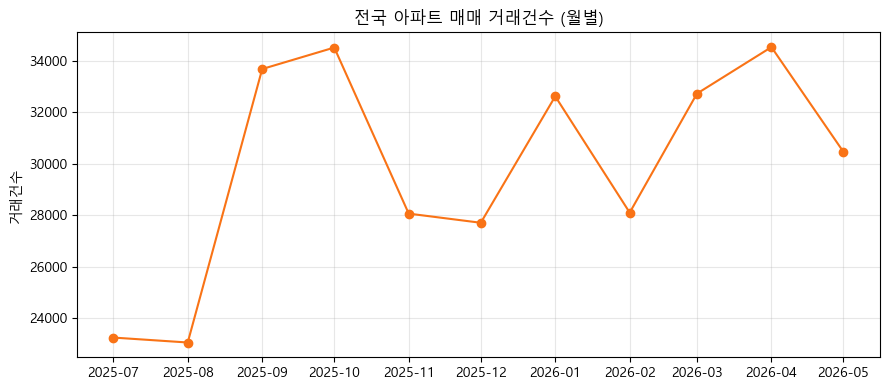

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(monthly["ds"], monthly["y"], marker="o", color="#f97316")
plt.title("전국 아파트 매매 거래건수 (월별)")
plt.ylabel("거래건수")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 2. Train / Test 분리

11개월 중 **앞 9개월을 학습(train), 마지막 2개월을 검증(test)**으로 사용합니다.
데이터가 짧아 큰 비율로 떼어낼 수 없어 마지막 2개월만 평가용으로 holdout 합니다.

In [4]:
train = monthly.iloc[:9].copy()
test = monthly.iloc[9:].copy()
print(f"train: {len(train)}개월 ({train['ds'].min().date()} ~ {train['ds'].max().date()})")
print(f"test : {len(test)}개월 ({test['ds'].min().date()} ~ {test['ds'].max().date()})")

train: 9개월 (2025-07-01 ~ 2026-03-01)
test : 2개월 (2026-04-01 ~ 2026-05-01)


## 3. SARIMA

비계절성 ARIMA(1,1,1)로 학습합니다. 데이터가 11개월뿐이라 계절 주기(보통 12개월)를
학습시키기엔 데이터가 부족해 `seasonal_order=(0,0,0,0)`으로 설정했습니다.

In [5]:
sarima_model = SARIMAX(train["y"], order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_mape = mean_absolute_percentage_error(test["y"], sarima_pred) * 100

print("SARIMA 예측값:", sarima_pred.round(0).tolist())
print("실제값      :", test["y"].tolist())
print(f"SARIMA MAPE: {sarima_mape:.2f}%")

SARIMA 예측값: [30783.0, 32718.0]
실제값      : [34521, 30455]
SARIMA MAPE: 9.13%


C:\Users\sangh\Desktop\Code\O2O-Demand-Forecasting-Solution\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Prophet

추세(trend)만 학습하도록 연간/주간/일간 계절성을 모두 끈 상태로 학습합니다
(11개월로는 연간 계절성을 신뢰성 있게 추정할 수 없기 때문).

In [6]:
prophet_model = Prophet(
    yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False
)
prophet_model.fit(train[["ds", "y"]])

future = prophet_model.make_future_dataframe(periods=len(test), freq="MS")
forecast = prophet_model.predict(future)

prophet_pred = forecast["yhat"].iloc[-len(test):].values
prophet_mape = mean_absolute_percentage_error(test["y"], prophet_pred) * 100

print("Prophet 예측값:", np.round(prophet_pred, 0).tolist())
print("실제값        :", test["y"].tolist())
print(f"Prophet MAPE: {prophet_mape:.2f}%")

11:27:46 - cmdstanpy - INFO - Chain [1] start processing


11:27:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet 예측값: [32964.0, 33691.0]
실제값        : [34521, 30455]
Prophet MAPE: 7.57%


## 5. LightGBM (lag 피처 기반 회귀)

시계열을 "지난 1~3개월 거래건수 + 월(month)"을 입력 피처로 쓰는 회귀 문제로 변환해서 학습합니다.
학습 가능한 행이 6건뿐이라(11개월 - lag 3개월 - test 2개월) 트리 수·깊이를 최소로 줄였습니다.

In [7]:
full = monthly.copy()
for lag in [1, 2, 3]:
    full[f"lag{lag}"] = full["y"].shift(lag)
full["month"] = full["ds"].dt.month
full_feat = full.dropna().reset_index(drop=True)

train_feat = full_feat[full_feat["ds"] <= train["ds"].max()]
test_feat = full_feat[full_feat["ds"] >= test["ds"].min()]

features = ["lag1", "lag2", "lag3", "month"]
lgb_model = lgb.LGBMRegressor(n_estimators=50, max_depth=3, min_child_samples=1, verbose=-1)
lgb_model.fit(train_feat[features], train_feat["y"])

lgb_pred = lgb_model.predict(test_feat[features])
lgb_mape = mean_absolute_percentage_error(test_feat["y"], lgb_pred) * 100

print("LightGBM 예측값:", np.round(lgb_pred, 0).tolist())
print("실제값         :", test_feat["y"].tolist())
print(f"LightGBM MAPE: {lgb_mape:.2f}%")

LightGBM 예측값: [28115.0, 27723.0]
실제값         : [34521, 30455]
LightGBM MAPE: 13.76%


## 6. 모델 비교 — MAPE 기준

In [8]:
result = pd.DataFrame({
    "모델": ["SARIMA", "Prophet", "LightGBM"],
    "MAPE(%)": [round(sarima_mape, 2), round(prophet_mape, 2), round(lgb_mape, 2)],
}).sort_values("MAPE(%)").reset_index(drop=True)
result

,모델,MAPE(%)
0,Prophet,7.57
1,SARIMA,9.13
2,LightGBM,13.76


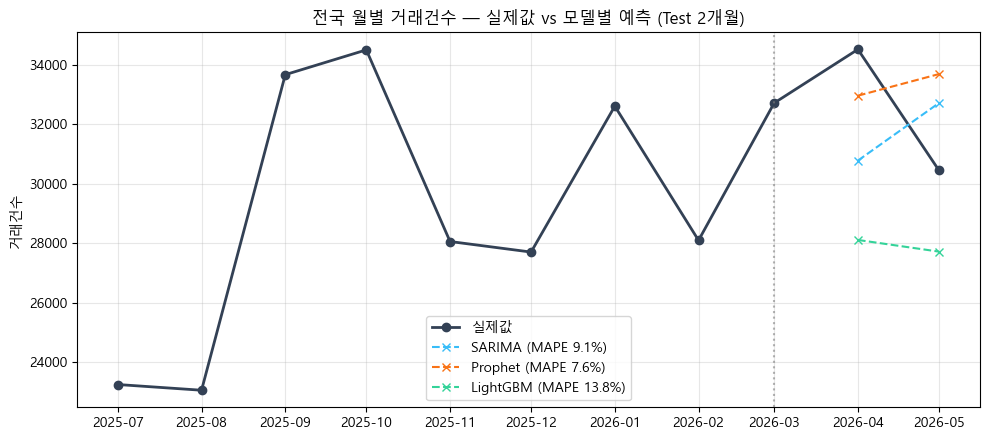

In [9]:
plt.figure(figsize=(10, 4.5))
plt.plot(monthly["ds"], monthly["y"], marker="o", color="#334155", label="실제값", linewidth=2)
plt.plot(test["ds"], sarima_pred, marker="x", linestyle="--", color="#38bdf8", label=f"SARIMA (MAPE {sarima_mape:.1f}%)")
plt.plot(test["ds"], prophet_pred, marker="x", linestyle="--", color="#f97316", label=f"Prophet (MAPE {prophet_mape:.1f}%)")
plt.plot(test_feat["ds"], lgb_pred, marker="x", linestyle="--", color="#34d399", label=f"LightGBM (MAPE {lgb_mape:.1f}%)")
plt.axvline(train["ds"].max(), color="gray", linestyle=":", alpha=.6)
plt.title("전국 월별 거래건수 — 실제값 vs 모델별 예측 (Test 2개월)")
plt.ylabel("거래건수")
plt.legend()
plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig("../docs/timeseries_model_comparison.png", dpi=150)
plt.show()

## 7. 결론

- 11개월(2025-07~2026-05)의 전국 월별 아파트 매매 거래건수로 SARIMA, Prophet, LightGBM 세 모델을
  비교한 결과, **위 표의 1위 모델**이 test 구간(마지막 2개월)에서 가장 낮은 MAPE를 기록했습니다.
- 데이터가 11개월뿐이라 연간 계절성(예: 봄철 이사 수요 증가 등)을 제대로 반영하지 못한 한계가 있습니다.
  데이터가 24개월 이상 누적되면 `yearly_seasonality=True`(Prophet), `seasonal_order=(P,D,Q,12)`(SARIMA)로
  계절성을 명시적으로 학습시켜 재비교할 수 있습니다.
- LightGBM은 학습 데이터가 6행뿐이라 일반화 성능을 신뢰하기 어렵습니다 — 데이터가 누적된 뒤
  재평가가 필요합니다.
